# Time series analysis on the data International Airline passengers from 1940 to 1960

In [19]:
!pip install statsmodels

In [20]:
!pip install statsmodels --no-cache-dir


In [21]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

In [22]:
df = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv")
df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [23]:
df.shape

(144, 2)

In [24]:
print(df.columns)

Index(['Month', 'Passengers'], dtype='object')


<Axes: xlabel='Month', ylabel='Passengers'>

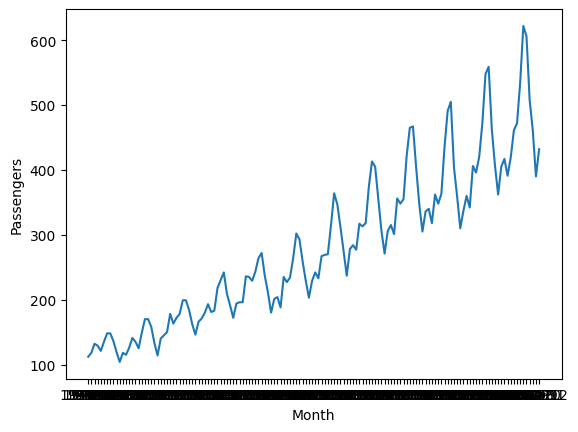

In [25]:
sns.lineplot(x="Month", y="Passengers", data=df)

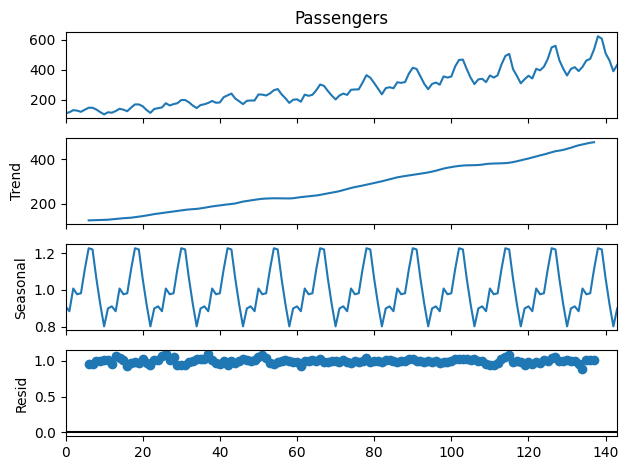

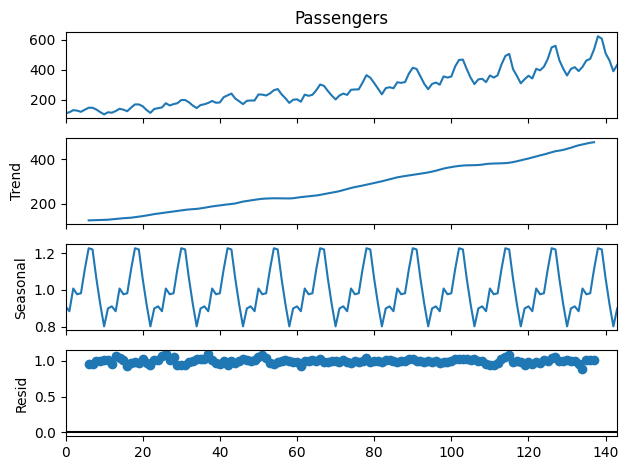

In [27]:
decompose = seasonal_decompose(df["Passengers"], model="multiplicative", period=12)
decompose.plot()

<Axes: >

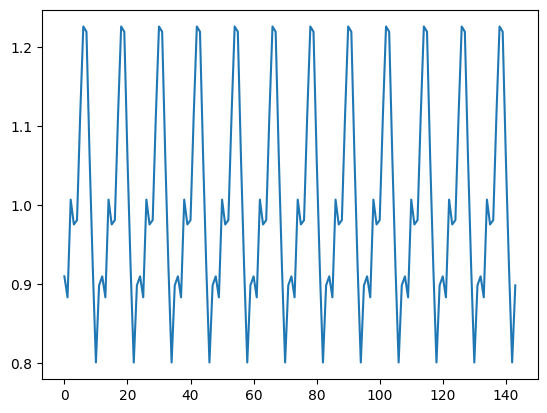

In [28]:
decompose.seasonal.plot()

In [29]:
trend = decompose.trend
seasonal = decompose.seasonal
residual = decompose.resid

In [30]:
df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


Epoch 1/100
11/11 [==============================] - 1s 14ms/step - loss: 49010.8203 - root_mean_squared_error: 221.3839
Epoch 2/100
11/11 [==============================] - 0s 9ms/step - loss: 21561.6328 - root_mean_squared_error: 146.8388
Epoch 3/100
11/11 [==============================] - 0s 9ms/step - loss: 7795.0581 - root_mean_squared_error: 88.2896
Epoch 4/100
11/11 [==============================] - 0s 8ms/step - loss: 3050.1211 - root_mean_squared_error: 55.2279
Epoch 5/100
11/11 [==============================] - 0s 9ms/step - loss: 2326.6174 - root_mean_squared_error: 48.2350
Epoch 6/100
11/11 [==============================] - 0s 11ms/step - loss: 2399.3577 - root_mean_squared_error: 48.9832
Epoch 7/100
11/11 [==============================] - 0s 10ms/step - loss: 2364.5801 - root_mean_squared_error: 48.6269
Epoch 8/100
11/11 [==============================] - 0s 12ms/step - loss: 2280.0027 - root_mean_squared_error: 47.7494
Epoch 9/100
11/11 [=============================

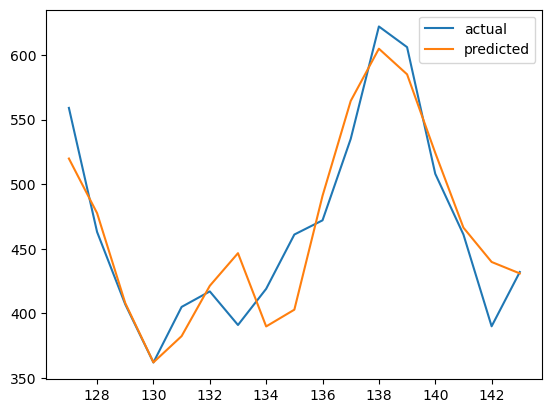

In [ ]:
from keras.models import Sequential
from keras.layers import Dense
from keras.metrics import RootMeanSquaredError

# split the data into training and testing sets
train_size = int(len(df) * 0.8)
train = df[:train_size]
test = df[train_size:]

# define the number of lagged time steps to use as input features
n_lags = 12

# create the input and output data for the neural network
X_train = np.array([train["#Passengers"].values[i:i+n_lags] for i in range(len(train)-n_lags)])
y_train = np.array(train["#Passengers"].values[n_lags:])
X_test = np.array([test["#Passengers"].values[i:i+n_lags] for i in range(len(test)-n_lags)])
y_test = np.array(test["#Passengers"].values[n_lags:])

# create the neural network model
model = Sequential()
model.add(Dense(10, input_dim=n_lags, activation="relu"))
model.add(Dense(1))
model.compile(loss="mean_squared_error", optimizer="adam", metrics=[RootMeanSquaredError()])

# train the neural network model
model.fit(X_train, y_train, epochs=100, batch_size=10, verbose=1)

# make predictions on the testing set using the trained model
predictions = model.predict(X_test)

# plot the actual and predicted values
plt.plot(test.index[-len(predictions):], test["#Passengers"].values[-len(predictions):], label="actual")
plt.plot(test.index[-len(predictions):], predictions, label="predicted")
plt.legend()
plt.show()
